In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

{(891, 12)}
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN  

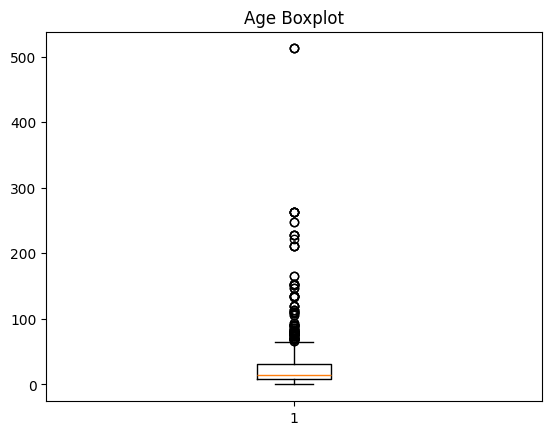

In [10]:
def clean_data(filepath):
    df = pd.read_csv(filepath)
    # Dataset shape
    print({df.shape})

    # First 5 rows
    print(df.head())

    # Inspect data types
    print(df.info())

    # Dropped Cabin column due to many NaNs.
    df = df.drop(columns=['Cabin'])

    # Fix data type
    df['PassengerId']   = df['PassengerId'].astype(str)
    df['Pclass'] = df['Pclass'].astype(str)


    # Replace NaNs with the median due to many outliers. Slide Number 53
    df["Age"] = df["Age"].fillna(df["Age"].median())
    # Check if values are below 0, and replace them with 0.
    df.loc[df["Age"] < 0, "Age"] = 0

    # Replaces missing values with the mode because it is catagorical. Slide Number 53
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Remove duplicates, if any.
    df.drop_duplicates(inplace=True)

    # perform Boxplot on the Fare column because it is most likly to have outliers.
    plt.boxplot(df['Fare'])
    plt.title('Age Boxplot')
    plt.show()

    # Cap outliers at 99th percentile
    df['Fare'] = df['Fare'].clip(upper=df['Fare'].quantile(0.99))

    return df


# Aplly function to Data.
df_clean = clean_data('/content/Titanic.csv')

In [11]:
# check that we have no missing values left after cleaning
if df_clean.isnull().sum().sum() == 0:
    print("Check 1 passed")
else:
    print("Check 1 failed - found nulls in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# age can't be 0 or negative
if (df_clean['Age'] > 0).all():
    print("No ages below 0 or 0")
else:
    print("Found zero or negative ages")

# we dropped Cabin so we should have 11 columns
if df_clean.shape[1] == 11:
    print("Data has the correct number of columns")
else:
    print(f"Expected 11 columns, got {df_clean.shape[1]}")

Check 1 passed
No ages below 0 or 0
Data has the correct number of columns
